## Figure 3 - Population responses across experience levels

This script generates Figure 3, showing population neural
responses to image changes and omissions across experience levels (Familiar, Novel, Novel+),
including single cell examples, population averages, response heatmaps, fraction of
responsive cells, and experience modulation indices.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse
import visual_behavior.ophys.response_analysis.cell_metrics as cm
import visual_behavior.dimensionality_reduction.clustering.processing as processing

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache


%matplotlib inline
%load_ext autoreload
%autoreload 2

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

folder = 'population_activity'

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

### Response metrics and multi-session dataframes 

In [4]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30

session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

#### Cell response metrics metrics

In [5]:
metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])

#### Multi session response dataframes

In [6]:
# Image changes
event_type = 'all'
conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

change_mdf = multi_session_df[multi_session_df.is_change == True]
image_mdf = multi_session_df[multi_session_df.is_change == False]

# Omissions
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]

# Per image
conditions = ['cell_specimen_id', 'is_change', 'image_name']
each_image_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)


print(len(change_mdf.ophys_experiment_id.unique()))
print(len(omission_mdf.ophys_experiment_id.unique()))
print(len(each_image_mdf.ophys_experiment_id.unique()))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_image_name_platform_experiment_table.feather
there are 1885 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table
400
401
401


#### Dataset objects for all experiments for one field of view (container)

In [7]:
ophys_container_ids = [829561794]

# Load dataset dict for single cell plotting
# ophys_container_ids = matched_cells_table.ophys_container_id.unique()[:4]
dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids,
                                                       platform_experiments,
                                                       dataset_dict=None)

833629926


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

834279496


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

835006071


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

## Plotting

### Population activity for image changes

#### Population mean response

In [8]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# df = image_mdf.copy()
# xlim_seconds = [-0.25, 0.75]

# ppf.plot_population_averages_for_cell_types_across_experience(
#     df, xlim_seconds=xlim_seconds, xlabel='Time from image onset (s)',
#     ylabel='', data_type=data_type, event_type='images',
#     interval_sec=0.5, save_dir=save_dir, folder='population_activity',
#     suffix='', ax=None)

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nn=12826 cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nn=467 cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nn=1196 cells'>, <Axes: >, <Axes: >],
      dtype=object)

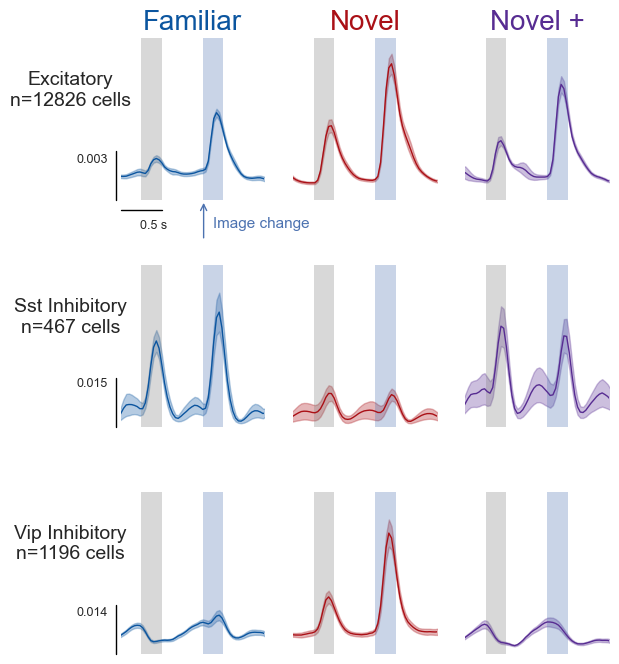

In [11]:
df = change_mdf.copy()
xlim_seconds = [-1., 0.75]

ppf.plot_population_averages_for_cell_types_across_experience(
    df, xlim_seconds=xlim_seconds, xlabel='Time from image change (s)',
    ylabel='Calcium events', data_type=data_type, event_type='changes',
    interval_sec=1, save_dir=save_dir, folder='population_activity',
    suffix='_changes_stacked', ax=None)

#### Quantification of mean response

array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean non-change image response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

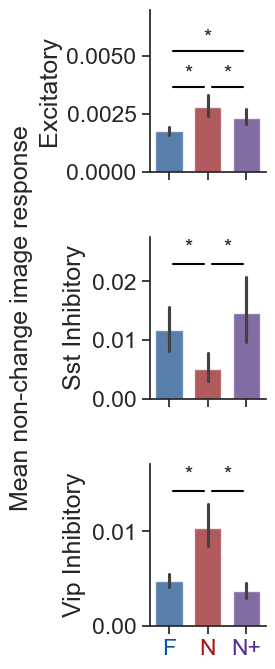

In [12]:
metric = 'mean_response_all_images'
ylabel = 'Mean non-change image response'

event_type = 'all'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean image change response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

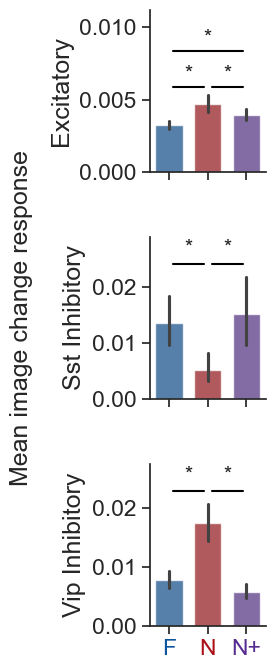

In [13]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'

event_type = 'changes'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', 
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean non-change image response - pref image\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

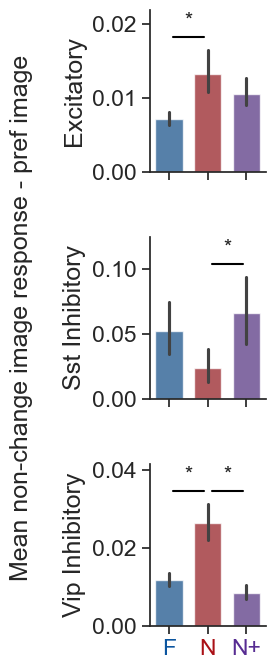

In [14]:
metric = 'mean_response_pref_image'
ylabel = 'Mean non-change image response - pref image'
event_type = 'pref_image'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



#### Percent responsive cells

Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Non-change image responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

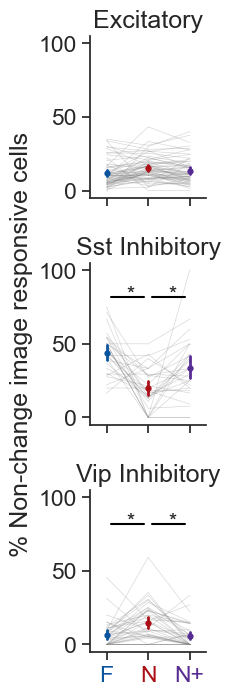

In [15]:
# Quantify fraction of cells responsive to their preferred stimulus
df = each_image_mdf[(each_image_mdf.is_change==False)& (each_image_mdf.pref_stim==True)]

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.2, ylim=(-5, 105), ylabel='% Non-change image responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_images_pref_stim', horizontal=False, ax=None, event_type='images')


Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Image change responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

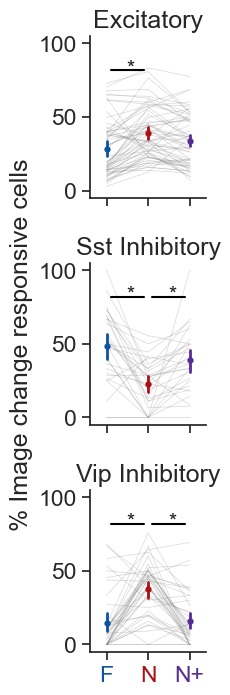

In [16]:
# Quantify fraction of cells responsive to their preferred stimulus
df = each_image_mdf[(each_image_mdf.is_change==True)& (each_image_mdf.pref_stim==True)]

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.2, ylim=(-5, 105), ylabel='% Image change responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_changes_pref_stim', horizontal=False, ax=None, event_type='changes')


#### Change modulation

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

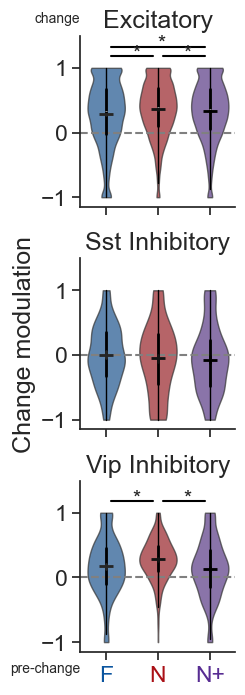

In [17]:
metric = 'change_modulation_index'
xlabel = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, label=xlabel, 
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, event_type='changes')


In [18]:
missing_ids = metrics_table.loc[
    ~metrics_table['ophys_experiment_id'].isin(change_mdf['ophys_experiment_id']),
    'ophys_experiment_id'].unique()

tmp = metrics_table[metrics_table.ophys_experiment_id.isin(missing_ids)==False]

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

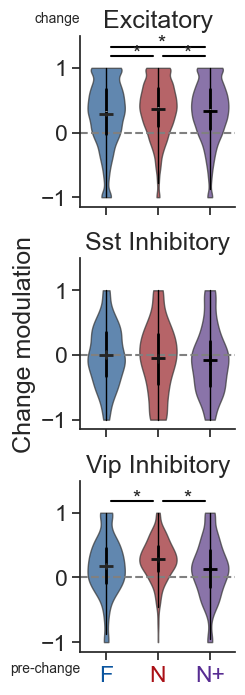

In [19]:
metric = 'change_modulation_index'
xlabel = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(tmp, metric, label=xlabel, 
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, event_type='changes')


In [20]:
print('image_mdf.mouse_id dtype:', image_mdf.mouse_id.dtype)
print('platform_cells_table.mouse_id dtype:', platform_cells_table.mouse_id.dtype)

image_mdf.mouse_id dtype: int64
platform_cells_table.mouse_id dtype: int64


#### Experience modulation

Quantification of how neural responses change across experience levels. Includes
experience modulation index (computed as the difference in mean response between
two experience levels divided by the sum) for each cell, shown as distributions
per cell type. Also shows mean image change response magnitude across cohorts,
depths, and cortical areas, and the change modulation index (response to image
changes minus response to non-change images, over the sum) split by area and
depth. Corresponds to PPT Figure S6 panels I-N.

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Experience modulation'>],
      dtype=object)

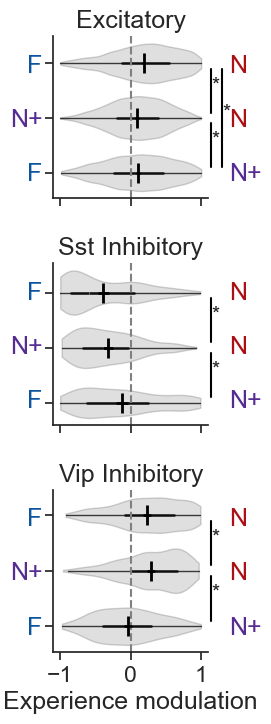

In [22]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated_by_cell_type(image_mdf, event_type, metric, platform_cells_table,
                                                            xlims=(-1.1, 1.1), xlabel=xlabel,
                                                            all_comparisons=True, horiz=False,
                                                            suptitle=None, suffix='', save_dir=None, ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4359: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4359: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4359: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])


array([<Axes: title={'center': 'Novel vs. Familiar'}>,
       <Axes: title={'center': 'Novel vs. Novel +'}>,
       <Axes: title={'center': 'Novel + vs. Familiar'}, xlabel='Experience modulation'>],
      dtype=object)

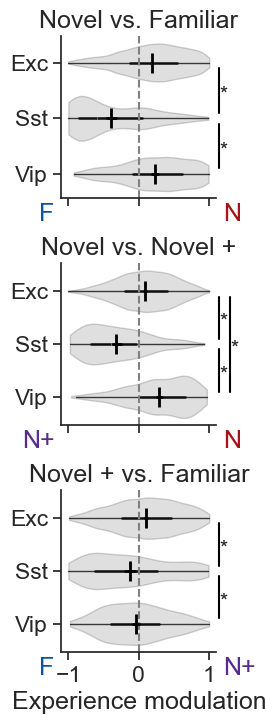

In [23]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated(
    image_mdf, event_type, metric, platform_cells_table,
    horiz=False, xlims=(-1.1, 1.1), xlabel='Experience modulation',
    suffix='_images_modulation', save_dir=save_dir,)

##### Experience vs change modulation 

### Population activity for image omissions

#### Population mean response

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nn=12826 cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nn=467 cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nn=1197 cells'>, <Axes: >, <Axes: >],
      dtype=object)

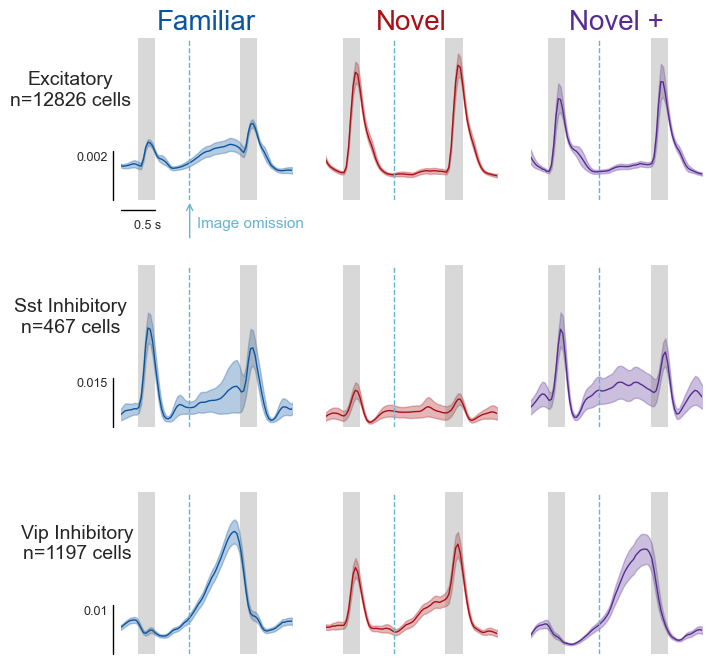

In [24]:
df = omission_mdf.copy()
xlim_seconds = [-1., 1.5]

ppf.plot_population_averages_for_cell_types_across_experience(
    df, xlim_seconds=xlim_seconds, xlabel='Time from image omission (s)',
    ylabel='Calcium events', data_type=data_type, event_type='omissions',
    interval_sec=1, save_dir=save_dir, folder='population_activity',
    suffix='', ax=None)

### Quantification of mean response

array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean image omission response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

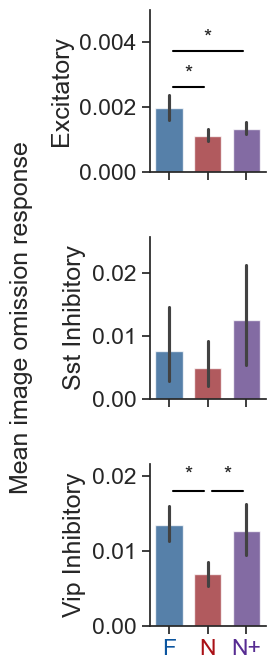

In [25]:
metric = 'mean_response_omissions'
ylabel = 'Mean image omission response'
event_type = 'omissions'

ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, plot_type='barplot', horiz=False,
    suptitle='', add_zero_line=False, event_type=event_type, data_type=data_type,
    ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)

#### Percent responsive cells 

Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Image omission responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

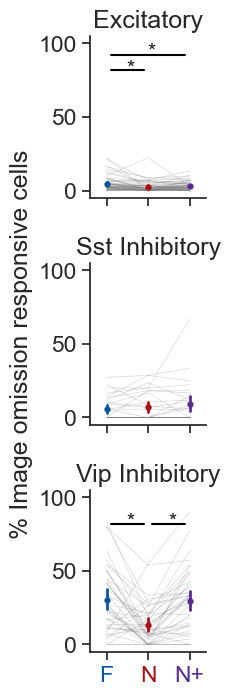

In [26]:
# Quantify fraction of cells responsive to their preferred stimulus
df = omission_mdf.copy()

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.1, ylim=(-5, 105), 
                                    ylabel='% Image omission responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_omissions_pref_stim', 
                                    horizontal=False, ax=None, event_type='omissions')


### Single cell diversity

Example container and cells for matched cell plotting

#### Matched cell response heatmaps

##### Image changes

Sst Inhibitory: dropping 8 of 200 matched cells not present in all 3 experience_level conditions
Vip Inhibitory: dropping 10 of 411 matched cells not present in all 3 experience_level conditions


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image onset (s)'>, <Axes: >], dtype=object)

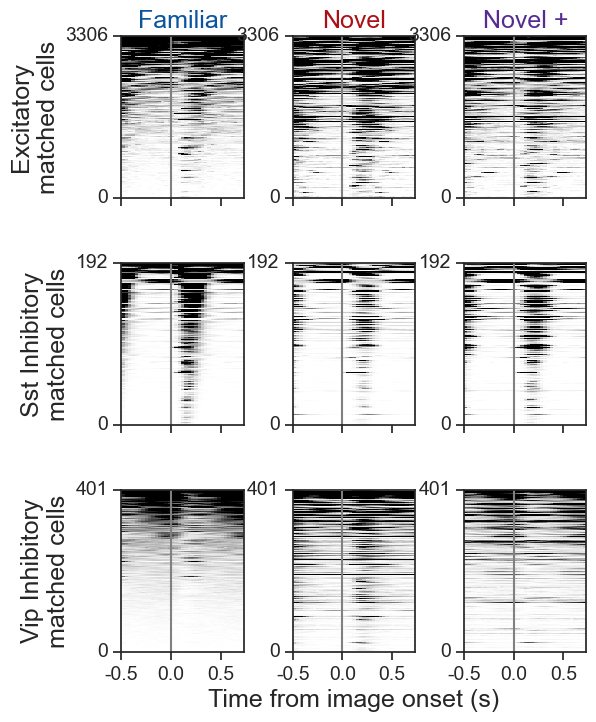

In [27]:
df = image_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'images'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          col_to_sort_by='mean_baseline', suptitle='', xlabel='Time from image onset (s)',
                                          match_cells=True, matched_cells_table=matched_cells_table,
                                          exp_to_match='Familiar', xlim_seconds=xlim_seconds, cbar=False,
                                          save_dir=save_dir, suffix='', ax=None)



array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

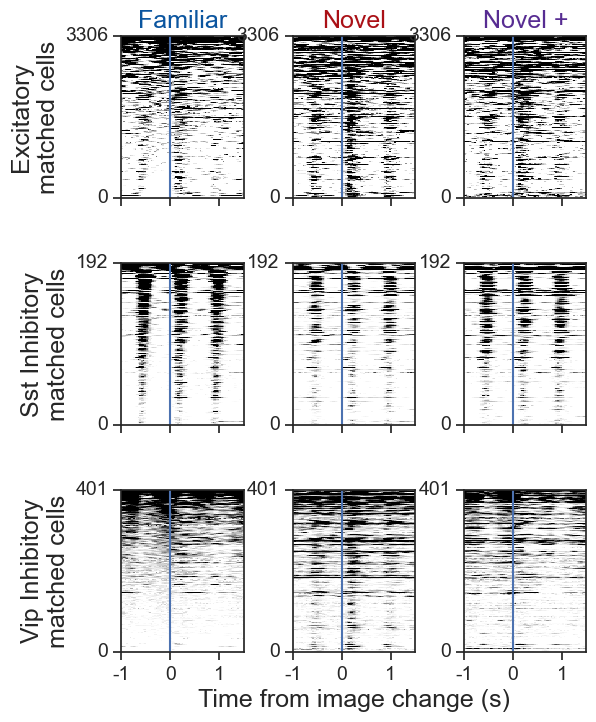

In [28]:
# Cell-matched response heatmaps for images
timestamps = change_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'
cols_to_sort_by = ['mean_response']

# Cell-matched population averages for changes
matched_changes = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(change_mdf)
xlim_seconds = [-1., 1.5]

# Cell-matched response heatmaps for changes
ppf.plot_response_heatmaps_for_conditions(
    matched_changes, timestamps, data_type, 'changes', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Changes',
    xlabel='Time from image change (s)', exp_to_match='Familiar', matched_cells_table=matched_cells_table,
    microscope=None, xlim_seconds=[-1, 1.5], match_cells=True, cbar=False,
    save_dir=save_dir, suffix='_matched_changes', ax=None)

##### Image omissions

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image omission (s)'>, <Axes: >],
      dtype=object)

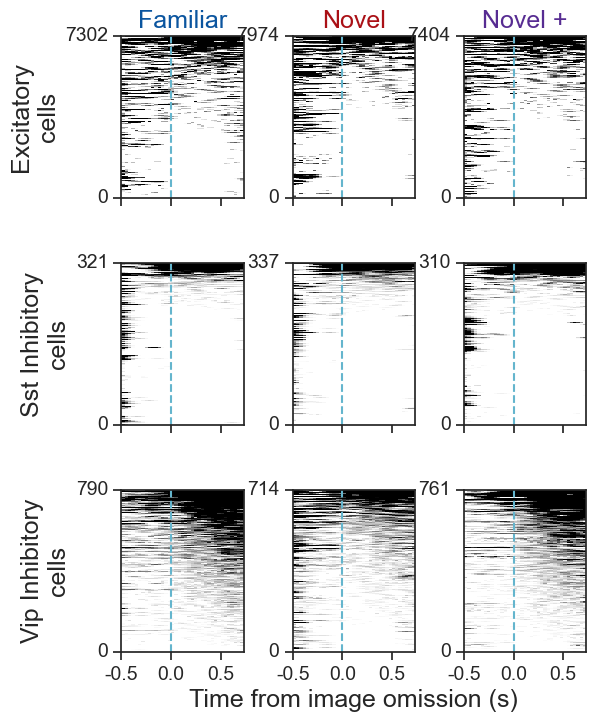

In [29]:
df = omission_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'omissions'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          col_to_sort_by='mean_response', suptitle='', xlabel='Time from image omission (s)',
                                          microscope=None, vmax=None, xlim_seconds=xlim_seconds, match_cells=False, cbar=False,
                                          save_dir=None, suffix='_heatmap_omissions', ax=None)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from omission (s)'>, <Axes: >], dtype=object)

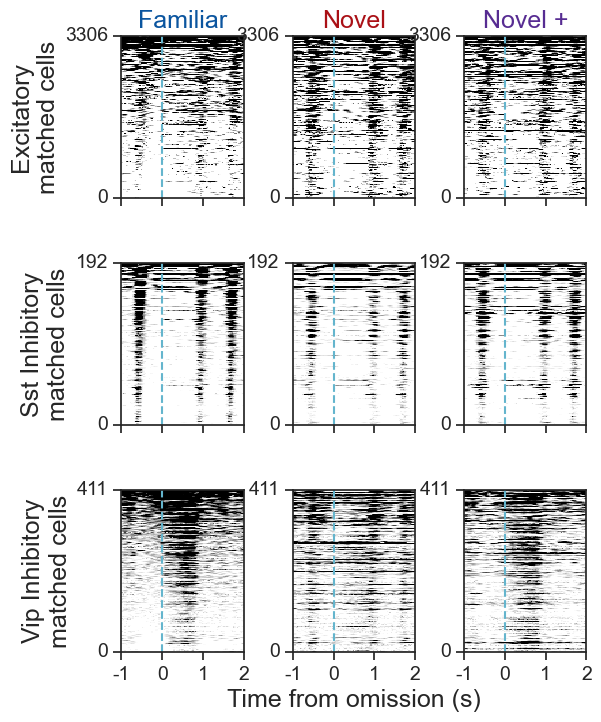

In [30]:
# Population averages for omissions - heatmaps
timestamps = omission_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

# Cell-matched omission heatmaps
matched_omissions = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(omission_mdf)

ppf.plot_response_heatmaps_for_conditions(
    matched_omissions, timestamps, data_type, 'omissions', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Omissions',
    xlabel='Time from omission (s)', exp_to_match='Familiar', matched_cells_table=matched_cells_table,
    microscope=None, xlim_seconds=[-1, 2], match_cells=True, cbar=False,
    save_dir=save_dir, suffix='_matched_omissions', ax=None)

#### Matched cell example responses across sessions 

In [31]:
Vip_containers = [1018027599, 1018027859, 1046576787, 1018027862, 1018028367]

Sst_containers = [1018028339, 1018028135, 1018028202, 1018028153, 1074913336]

Exc_containers = [1018027663, 1018027790, 1018028046, 1074922997, 1079028117, 1018027775,]


##### Image changes

In [32]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


###### Excitatory

In [33]:
# Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
#                      1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

# event_type = 'images'
# cell_type = 'Excitatory'

# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Exc_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_images_selected')


In [34]:
# Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
#                      1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

# event_type = 'changes'

# cell_type = 'Excitatory'
# pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [35]:
# Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  1086514606, 
#                      1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, 1086558285, 1086519596, 1086529704, ]

# event_type = 'changes'

# cell_type = 'Excitatory'
# pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [36]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


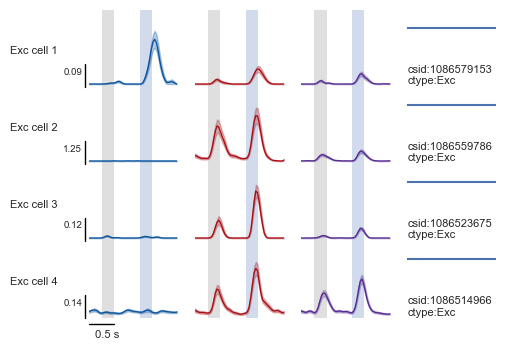

In [37]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Exc_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Exc_changes')
    


In [38]:
Exc_change_cells = matched_cells_table[(matched_cells_table.cell_type=='Excitatory') & 
                                        (matched_cells_table.project_code=='VisualBehavior') &
                                        (matched_cells_table.binned_depth==175)].cell_specimen_id.unique()
Exc_change_cells = np.random.choice(Exc_change_cells, 10)

In [39]:
# for cell_specimen_id in Exc_change_cells:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


###### Sst Inhibitory

In [40]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'images'
# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [41]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'changes'

# pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [42]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'changes'

# pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [43]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'changes'

# pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


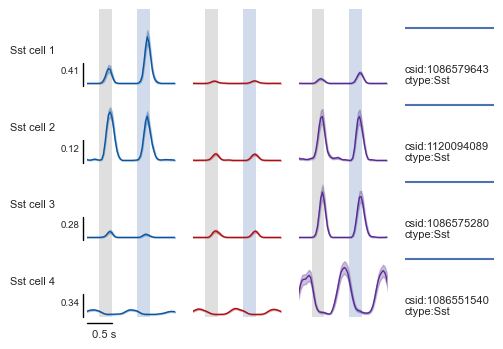

In [44]:
Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]

cell_type = 'Sst Inhibitory'
event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Sst_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Sst_changes')
    

In [45]:
    
# for cell_specimen_id in Sst_change_cells[:4]:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


###### Vip Inhibitory

In [46]:
# Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 

# itory'
# event_type = 'images'
# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Vip_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [47]:

# Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 
# # 1086627395, 1086673073, 1086519532, 1086516885, 1086615418, ]
# event_type='changes'
# cell_type = 'Vip Inhibitory'
# pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [48]:
# event_type='changes'
# cell_type = 'Vip Inhibitory'
# pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


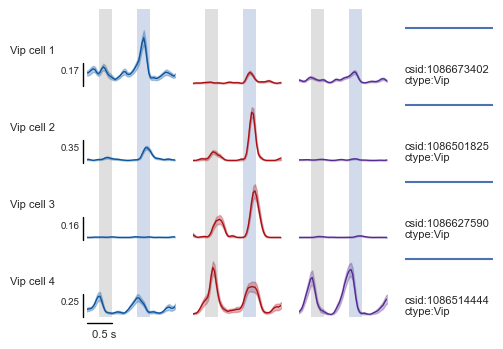

In [49]:
Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 

event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Vip_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Vip_changes')
    


In [50]:
# for cell_specimen_id in Vip_change_cells[4:]:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


##### Image omissions

In [51]:
# Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
#                       1086530117, 1120090879,  1086526518,]
# event_type = 'omissions'

# cell_type = 'Excitatory'
# pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [52]:
# Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
#                       1086530117, 1120090879,  1086526518,]
# event_type = 'omissions'

# pse.plot_selected_cell_examples(omission_mdf, Exc_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Exc_omissions')
    


In [53]:
# cell_types = utils.get_cell_types()
# cell_type = 'Excitatory'
# # for cell_type in cell_types: 
# event_type = 'omissions'
# # get reliable cells for this cell type
# reliable_cells = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (omission_mdf.mean_response > 0.1) &
#             (omission_mdf.cell_type==cell_type)]
# reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
# cells_to_plot = reliable_cells.cell_specimen_id.unique()
# print(len(cells_to_plot))

# pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

In [54]:
# Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
#                      1086620900,  1086556653, 1086559850, 1086619649,]

# event_type = 'omissions'

# cell_type = 'Sst Inhibitory'
# pse.plot_reliable_example_cells(omission_mdf, Sst_omission_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [55]:
# Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
#                      1086620900,  1086556653, 1086559850, 1086619649,]

# event_type = 'omissions'

# pse.plot_selected_cell_examples(omission_mdf, Sst_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Sst_omissions')
    


In [56]:
# cell_types = utils.get_cell_types()
# cell_type = 'Sst Inhibitory'
# # for cell_type in cell_types: 
# event_type = 'omissions'
# # get reliable cells for this cell type
# reliable_cells = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (omission_mdf.mean_response > 0.1) &
#             (omission_mdf.cell_type==cell_type)]
# reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
# cells_to_plot = reliable_cells.cell_specimen_id.unique()
# print(len(cells_to_plot))

# pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

In [57]:
# Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]
                      
# event_type = 'omissions'

# cell_type = 'Vip Inhibitory'
# pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [58]:
# Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]
                      
# event_type = 'omissions'


# pse.plot_selected_cell_examples(omission_mdf, Vip_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Vip_omissions')
    


#### Across cre examples for omissions

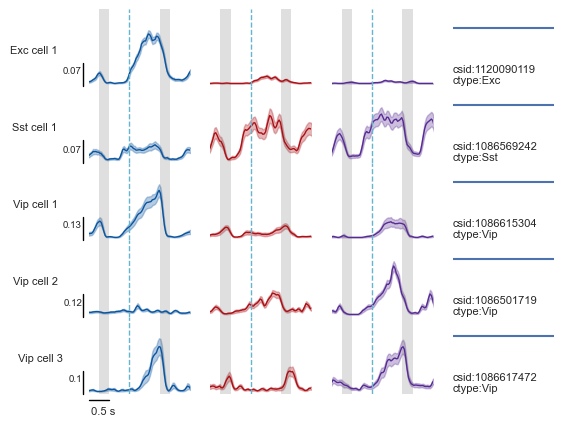

In [59]:
cells_to_plot = [1120090119, # Exc
                 1086569242, # Sst
                 1086615304, # Vip
                 1086501719, # Vip
                 1086617472, # Vip
                ]
event_type = 'omissions'

pse.plot_selected_cell_examples(omission_mdf, cells_to_plot, event_type=event_type,
                                xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_omissions')
    

#### Plot ROI zoom for example cells 

In [60]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# cells_to_plot = [1120090119, # Exc
#                  1086569242, # Sst
#                  1086615304, # Vip
#                  1086501719, # Vip
#                  1086617472, # Vip
#                 ]

# cell_specimen_id = cells_to_plot[0]

# for cell_specimen_id in cells_to_plot:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)
    

### Matched cell examples

cell_specimen_id: 1086514606
experience_level: Familiar
ophys_experiment_id: 989213060


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 991852002


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

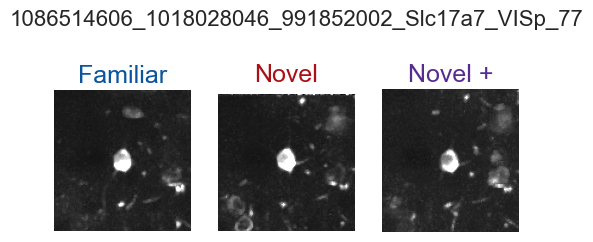

In [62]:
cell_specimen_id = 1086514606 #Excitatory behavior coding cell

pse.plot_matched_rois(cell_specimen_id, platform_cells_table,
                                        folder='matched_rois', save_dir=None)

cell_specimen_id: 1086628708
experience_level: Familiar
ophys_experiment_id: 882551935


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 885146239


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

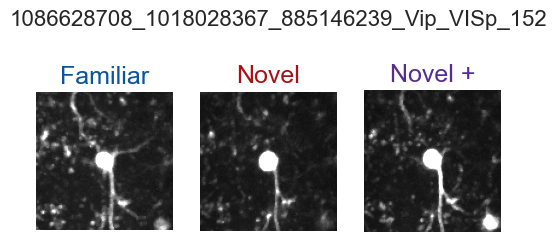

In [63]:
cell_specimen_id = 1086628708  

pse.plot_matched_rois(cell_specimen_id, platform_cells_table,
                                        folder='matched_rois', save_dir=None)

cell_specimen_id: 1086551540
experience_level: Familiar
ophys_experiment_id: 850517352


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 853363749


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 854759900


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

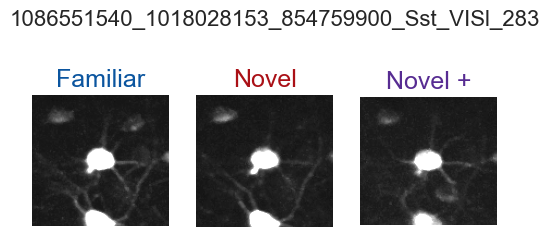

In [64]:
cell_specimen_id = 1086551540  

pse.plot_matched_rois(cell_specimen_id, platform_cells_table,
                                        folder='matched_rois', save_dir=None)

cell_specimen_id: 1086501719
experience_level: Familiar
ophys_experiment_id: 847267622


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 849233396


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 851085100


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

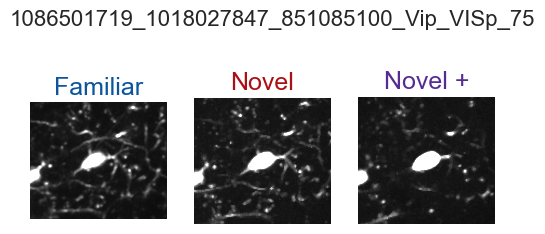

In [65]:
cell_specimen_id = 1086501719

pse.plot_matched_rois(cell_specimen_id, platform_cells_table,
                                        folder='matched_rois', save_dir=None)

#### ROIs and traces across sessions

In [66]:
ophys_container_id = 835006071 
ophys_container_id = 829561794

In [67]:
# cell_type = 'Excitatory'

# # Get high SNR matched cells for container
# matched_cells_snr, dff_metrics = pse.get_high_snr_matched_cells_for_container(ophys_container_id, dataset_dict,
#                                                                                matched_cells_table, platform_experiments, 
#                                                                                )

# # Plot matched max projections for container
# # Note: function signature is (ophys_container_id, platform_experiments, dataset_dict, save_dir, ax)
# # matched_cells_table is NOT a parameter
# pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
#                                               dataset_dict,
#                                               save_dir=save_dir, ax=None)



In [68]:
# n_reliable_cells_threshold = 5

# reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (change_mdf.mean_response > 0.02) &
#             (change_mdf.cell_type==cell_type) & 
#             (change_mdf.ophys_experiment_id.isin(platform_experiments.index.unique()))]

# # reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
# matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]


In [69]:
# start_times = np.asarray([512])
# duration_seconds = 18

# matched_cells = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id]
# matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
# matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
# matched_cells = matched_cells.cell_specimen_id.values
# print(len(matched_cells))

In [70]:
# start_times = np.asarray([513])

# csids = [1086502440, 
#          1086500171,
#          1086502886,
#          1086501666, 
#          1086529369]

# pse.plot_matched_rois_and_traces_for_container(ophys_container_id, dataset_dict,
#                                         matched_cells_table, platform_experiments, fontsize=12,
#                                         start_times=start_times, duration_seconds=18,
#                                         matched_cells=csids, save_dir=save_dir, suffix='')

In [71]:

# suffix = '_reliable_cells_selected'

# pse.plot_matched_traces_across_sessions(ophys_container_id, dataset_dict, 
#                                     matched_cells_table, platform_experiments, 
#                                     change_mdf, omission_mdf, cell_type, skip_behavior=True,
#                                     start_times=start_times, duration_seconds=duration_seconds,
#                                     matched_cells=matched_cells, save_dir=save_dir, suffix=suffix)

## Composite figure (Figure 3 main)
Gutter-aware panel placement via `panel_grid`. Run the data-loading and per-panel plotting cells above first, then the import cell, then the composite cell.

In [72]:
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, show_decoration_zones,
    check_label_overlap, auto_fit_left, snug_left_to_gutter, snug_top_to_gutter, auto_fit_bottom,
)


Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers
Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1570: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3715: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=e

Excitatory includes 62 containers


...

experience_level: Novel
ophys_experiment_id: 849233396


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 851085100


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

OVERLAP: axes of panel "C" intrudes into panel "C" (top gutter)
OVERLAP: axes of panel "A" intrudes into panel "A" (top gutter)
OVERLAP: axes of panel "H" intrudes into panel "H" (top gutter)
OVERLAP: axes of panel "E" intrudes into panel "E" (top gutter)
OVERLAP: axes of panel "E" intrudes into panel "E" (top gutter)
OVERLAP: axes of panel "E" intrudes into panel "E" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "F" intrudes into panel "F" (top gutter)
OVERLAP: axes of panel "G" intrudes into panel "G" (top gutter)
OVERLAP: axes of panel "G" intrudes into panel "G" (top gutter)
OVERLAP: axes of panel "G" intrudes into panel "G" (top gutter)
OVERLAP: axes of panel "J" intrudes into panel "J" (top gutter)
OVERLAP: axes of panel "J" intrudes into panel "J" (top gutter)
OVERLAP: axes of panel "J" intrudes into panel "J" (top gutter)


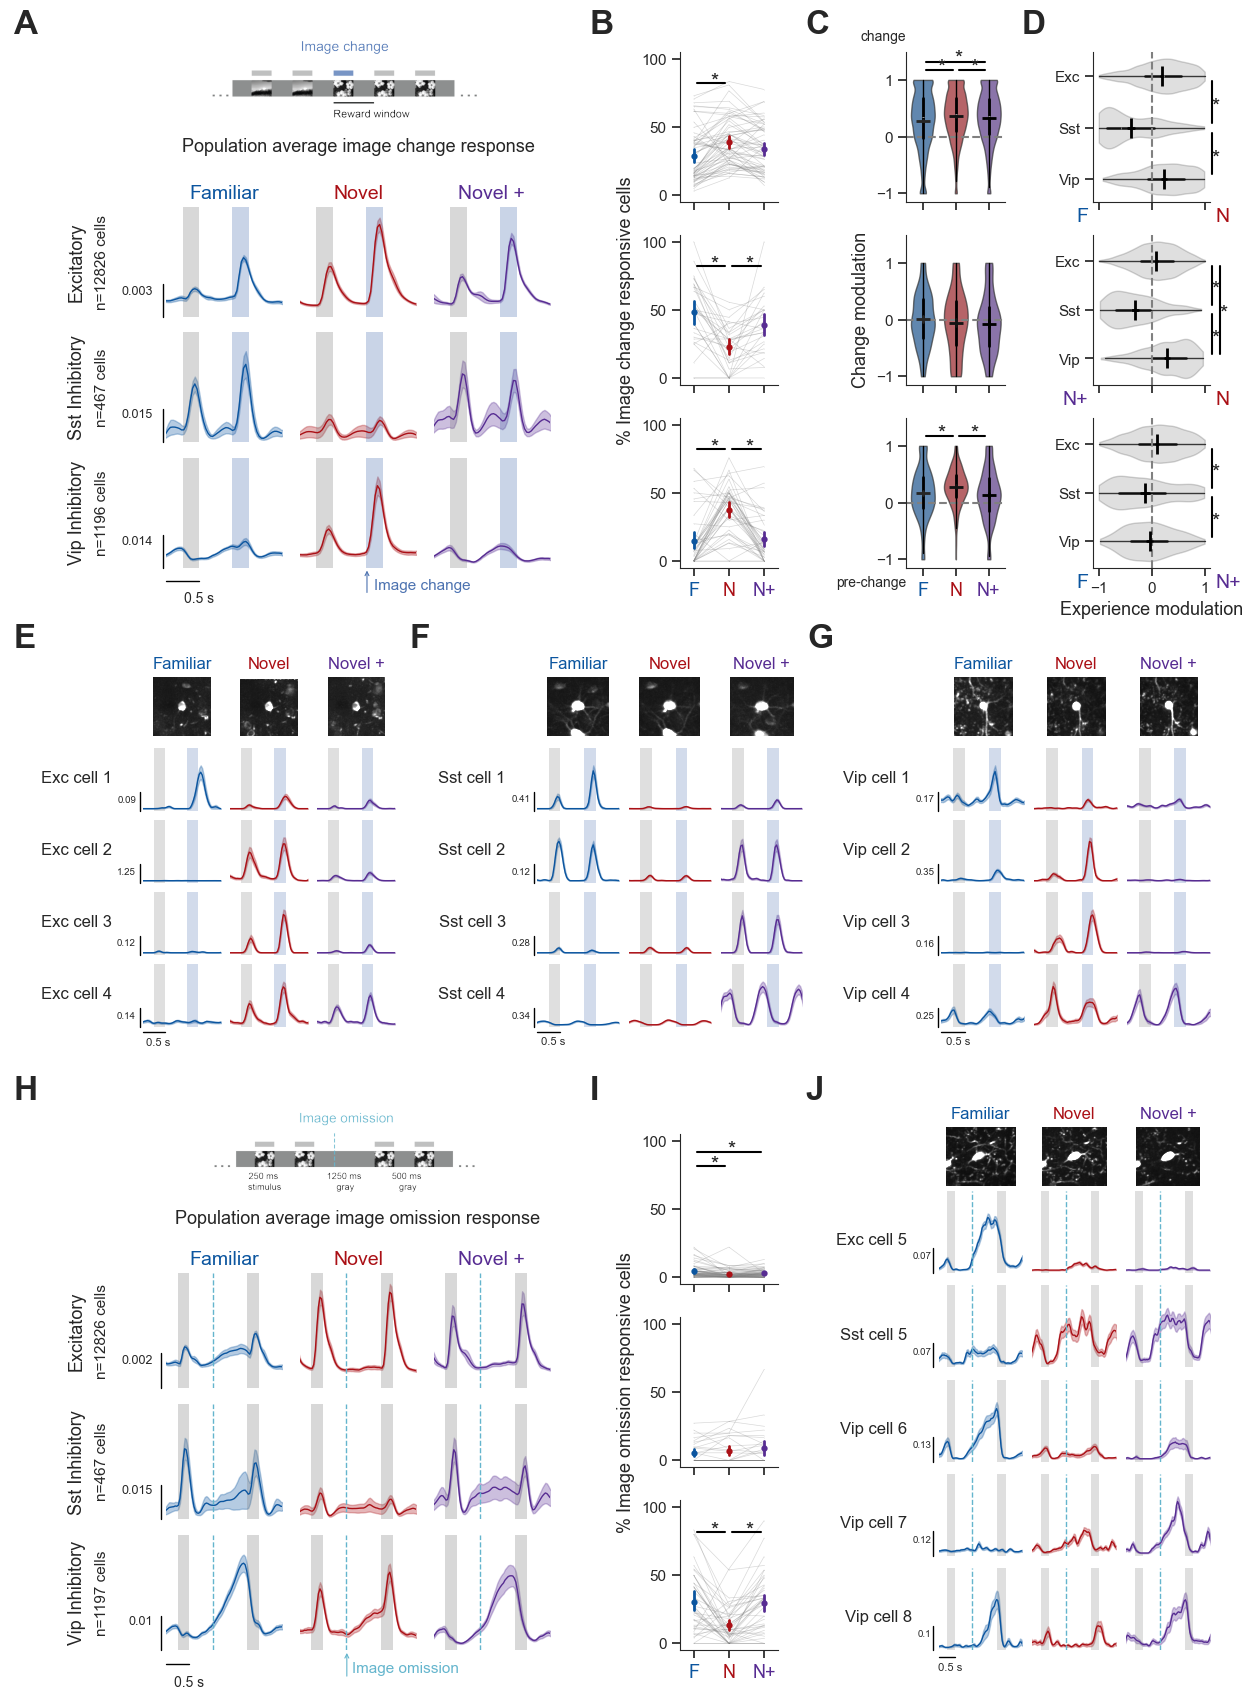

In [78]:
# Composite Figure 3 main - population responses across experience levels
#   Change block:  A pop-avg change (3 cell types x 3 experience) w/ image_change schematic header
#                  B % change-responsive cells | C change modulation | D experience modulation
#                  E/F/G Exc/Sst/Vip example cells (4 cells x 3 exp) each w/ matched-ROI strip
#   Omission block: H pop-avg omission w/ image_omission schematic header
#                   I % omission-responsive cells | J omission example cells (5 cells x 3 exp) + ROI strip
#
# figsize + REGIONS derived from the measured "Figure 3" slide geometry (v6 pptx) and
# tuned against a data-free mock until check_label_overlap was clean. Panels embed LIVE:
#   B/C/D/I  -> ax=list of 3   (functions already support ax=)
#   A/H      -> built inline via plot_population_averages_for_conditions per cell type
#   E/F/G/J  -> plot_selected_cell_examples(ax=flat list, show_metadata_col=False)
#               + plot_matched_rois(ax=3-list) for the ROI strip
#   schematics (A/H) loaded from PNGs via plt.imread
#
# UPSTREAM (run the data-loading cells above first so these stable vars exist):
#   data_type, change_mdf, image_mdf, omission_mdf, each_image_mdf, metrics_table,
#   platform_cells_table, save_dir.
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import visual_behavior.visualization.ophys.summary_figures as sf

# ---------------------------------------------------------------- layout ----
# measured slide geometry (slide fraction) -> figure-fraction REGIONS
SLIDE_W_IN, SLIDE_H_IN = 7.5, 10.0
S = {  # [sx0, sx1, sy0, sy1]  (letter/header top-left -> content bottom-right)
    'A': [0.0050, 0.4200, 0.0926, 0.4150],   # wider (further left + right)
    'B': [0.4400, 0.5950, 0.0926, 0.4150],   # wider; same height as A/I
    'C': [0.6050, 0.7600, 0.0926, 0.4150],   # wider
    'D': [0.7700, 0.9100, 0.0926, 0.4150],   # shifted right
    'E': [0.0050, 0.3000, 0.4450, 0.6700],   # E-G span full width
    'F': [0.3050, 0.6050, 0.4450, 0.6700],
    'G': [0.6100, 0.9100, 0.4450, 0.6700],
    'H': [0.0050, 0.4200, 0.7000, 1.0224],   # wider; same as A
    'I': [0.4400, 0.5950, 0.7000, 1.0224],   # wider; same x-range + height as B
    'J': [0.6050, 0.9100, 0.7000, 1.0224],   # same bottom edge as H/I
}
crop_x0 = min(v[0] for v in S.values()); crop_x1 = max(v[1] for v in S.values())
crop_y0 = min(v[2] for v in S.values()); crop_y1 = max(v[3] for v in S.values())
aspect = ((crop_x1 - crop_x0) * SLIDE_W_IN) / ((crop_y1 - crop_y0) * SLIDE_H_IN)
FIG_W = 12.0; FIG_H = round(FIG_W / aspect, 1)   # ~ (12.0, 15.8)

def _to_region(sx0, sx1, sy0, sy1):
    return [(sx0 - crop_x0) / (crop_x1 - crop_x0), (sx1 - crop_x0) / (crop_x1 - crop_x0),
            (sy0 - crop_y0) / (crop_y1 - crop_y0), (sy1 - crop_y0) / (crop_y1 - crop_y0)]
REGIONS = {k: _to_region(*v) for k, v in S.items()}

GUT = (20, 28)
# per-panel left decoration setback (pt); tuned on the mock, nudge on the real render
DP = {'A': (84, 0), 'B': (58, 0), 'C': (58, 0), 'D': (58, 0),   # A/H bigger -> plots shift right (letter stays)
      'E': (44, 0), 'F': (44, 0), 'G': (44, 0),
      'H': (84, 0), 'I': (58, 0), 'J': (44, 0)}

# ---------------------------------------------------------------- constants ----
# curated example cells (mirrors notebook cells 66/75/81/95; hard-coded here so the
# composite doesn't depend on exploratory vars that later cells overwrite)
Exc_change_cells = [1086579153, 1086559786, 1086523675, 1086514966]
Sst_change_cells = [1086579643, 1120094089, 1086575280, 1086551540]
Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444]
omission_cells   = [1120090119, 1086569242, 1086615304, 1086501719, 1086617472]
# representative cell whose matched-ROI strip is shown atop each example panel
ROI_CELL = {'E': 1086514606, 'F': 1086551540, 'G': 1086628708, 'J': 1086501719}
CELL_LABEL_FS = 12      # "Exc cell 1" row labels (plot_selected_cell_examples hardcodes 8)
# J example-cell row labels continue E-G numbering (E-G have 4 cells each)
J_LABELS = ['Exc cell 5', 'Sst cell 5', 'Vip cell 6', 'Vip cell 7', 'Vip cell 8']
ROI_TITLE_DELTA = -6    # shrink the ROI-strip Familiar/Novel/Novel+ titles by 6 pt
# A/H left row labels (rotated 90, centered on each row's y-axis)
CT_FS, N_FS = 13, 11            # cell-type name (bigger) vs n-cells (unchanged) font sizes
CT_OFFSET_PT, N_OFFSET_PT = 64, 46   # left offset (pt) of the cell-type / n-cells labels from the spine
# B/C/D/I axis text + spines
AXIS_LABEL_FS, TICK_FS = 13, 11
SPINE_LW = 0.8
# schematic PNG nudge (figure fraction): left(+) / up(+). positive DY pulls png UP to the gutter
SCHEM_DX, SCHEM_DY = 0.012, 0.010
# standard image-change / image-omission colors (used everywhere else in the paper)
CHANGE_COLOR = sns.color_palette()[0]
OMISSION_COLOR = sns.color_palette()[9]
# informative panel title over A/H, centered on the middle column
TITLE_A = 'Population average image change response'
TITLE_H = 'Population average image omission response'
INFO_TITLE_FS = 13
INFO_TITLE_GAP = 0.010      # figure-fraction gap between schematic and the title below it
# change/omission arrow (A/H): thinner + smaller head to match the originals
ARROW_LW, ARROW_SCALE = 0.8, 7
D_ANNOT_DELTA = -4          # shrink D's F / N / N+ side annotations by 4 pt

SCHEMATIC_DIR = '/Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/schematics/Figure 1'
SCHEM = {'A': os.path.join(SCHEMATIC_DIR, 'image_change.png'),
         'H': os.path.join(SCHEMATIC_DIR, 'image_omission.png')}

EXP = ['Familiar', 'Novel', 'Novel +']
exp_colors = utils.get_experience_level_colors()
cell_types = ['Excitatory', 'Sst Inhibitory', 'Vip Inhibitory']

# B input: non-change vs change responsive on preferred image
each_change_pref = each_image_mdf[(each_image_mdf.is_change == True) & (each_image_mdf.pref_stim == True)]

# ---------------------------------------------------------------- figure ----
fig = plt.figure(figsize=(FIG_W, FIG_H)); fig_setup(fig)

def plot_pop_avg_block(axgrid, mdf, event_type, xlim, arrow_label, arrow_color):
    """A/H: 3 cell-types (rows) x 3 experience (cols) population averages, built inline
    (the library wrapper's ax= path is broken; the inner per-condition fn works)."""
    dist = xlim[1] * 0.07
    for i, cell_type in enumerate(cell_types):
        row = list(np.atleast_1d(axgrid[i]))
        df_ct = mdf[mdf.cell_type == cell_type]
        ppf.plot_population_averages_for_conditions(
            df_ct, data_type, event_type, 'experience_level', 'experience_level',
            horizontal=True, legend=False, xlim_seconds=xlim, interval_sec=1,
            palette=exp_colors, ax=row)
        # scale bar + n-cells label on the first (Familiar) column
        scale = 1.06 if cell_type == 'Excitatory' else 1.15
        _, ymax = row[0].get_ylim(); row[0].set_ylim(0, ymax * scale)
        _, ymax = row[0].get_ylim()
        row[0].set_yticks([0, np.round(ymax * .3, 3)])
        row[0].set_yticklabels(['', np.round(ymax * .3, 3)], va='top', fontsize=9)
        row[0].axvline(x=xlim[0] - dist, ymin=0, ymax=0.3, color='k', linewidth=1, clip_on=False)
        n_cells = df_ct.cell_specimen_id.nunique()
        row[0].set_ylabel('')
        # cell-type label rotated 90 & centered on the row's y-axis; n-cells smaller, just inside it
        row[0].annotate(cell_type, xy=(0, 0.5), xycoords='axes fraction',
                        xytext=(-CT_OFFSET_PT, 0), textcoords='offset points',
                        rotation=90, fontsize=CT_FS, ha='center', va='center', annotation_clip=False)
        row[0].annotate(f'n={n_cells} cells', xy=(0, 0.5), xycoords='axes fraction',
                        xytext=(-N_OFFSET_PT, 0), textcoords='offset points',
                        rotation=90, fontsize=N_FS, ha='center', va='center', annotation_clip=False)
        # exp-level column titles only on the top (Excitatory) row
        for j in range(3):
            row[j].set_title(EXP[j] if i == 0 else '', color=exp_colors[j], fontsize=14)
            row[j].set_xlabel('')
        # col-0: strip spines / ticks / xticklabels but keep the manual scale bar + y-scale label
        sns.despine(ax=row[0], top=True, right=True, left=True, bottom=True)
        row[0].tick_params(bottom=False, left=False, right=False, top=False, labelbottom=False)
        row[0].set_xticks([])
        # cols 1,2: hide frames entirely (traces stay visible)
        for j in (1, 2):
            row[j].axis('off')
        # change/omission arrow on the BOTTOM (Vip) row, Novel column (clear of the 0.5s bar on col-0)
        if i == len(cell_types) - 1:
            xa = 1
            row[xa].annotate(arrow_label, xy=(0.12, -0.1), xycoords=row[xa].get_xaxis_transform(),
                             ha='left', va='top', color=arrow_color, fontsize=11, clip_on=False)
            row[xa].annotate('', xy=(0.01, -0.25), xycoords=row[xa].get_xaxis_transform(), xytext=(0.01, 0),
                             arrowprops=dict(arrowstyle='<-', color=arrow_color, lw=ARROW_LW,
                                             mutation_scale=ARROW_SCALE), clip_on=False)
        # 0.5 s scale bar on the bottom-row first column (like E-G)
        if i == len(cell_types) - 1:
            ymn, ymx = row[0].get_ylim()
            xfrac = 0.5 / (np.abs(xlim[0]) + xlim[1])   # 0.5 s as a fraction of the x-range (axes coords)
            y_time = (ymx - ymn) * 0.12
            row[0].axhline(y=-y_time, xmin=0, xmax=xfrac, color='k', linewidth=1, clip_on=False)
            row[0].annotate('0.5 s', xy=(xlim[0], -y_time * 1.8), xycoords='data',
                            xytext=(xlim[0] + 0.5, -y_time * 1.8), ha='center', va='top',
                            fontsize=10, clip_on=False, annotation_clip=False)

# ---- A: change population averages (+ image_change schematic header later) ----
axA = np.array(panel(fig, REGIONS['A'][:2], REGIONS['A'][2:], 'A', dim=(3, 3),
                     has_title=True, title_lines=2, title_room_pt=52, hspace=0.14, wspace=0.15,
                     sharey='row', gutter_pt=GUT, decoration_pt=DP['A']), dtype=object)
plot_pop_avg_block(axA, change_mdf, 'changes', [-1, 0.75], 'Image change', CHANGE_COLOR)

# ---- B: % change-responsive cells ----
axB = list(np.atleast_1d(panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', dim=(3, 1),
                               has_title=True, hspace=0.22, sharex=True, gutter_pt=GUT, decoration_pt=DP['B'])))
ppf.plot_percent_responsive_cells(each_change_pref, responsiveness_threshold=0.2, ylim=(-5, 105),
                                  ylabel='% Image change responsive cells', horizontal=False,
                                  event_type='changes', save_dir=None, ax=axB)
for _a in axB:
    _a.set_title('')
for _a in axB[:-1]:                       # shared x -> labels only on bottom subplot
    _a.tick_params(labelbottom=False); _a.set_xlabel('')
axB[1].yaxis.label.set_size(AXIS_LABEL_FS)
for _a in axB:
    _a.tick_params(labelsize=TICK_FS)
    _a.tick_params(axis='x', labelsize=TICK_FS + 2)   # bigger F/N/N+ labels
    for _s in _a.spines.values():
        _s.set_linewidth(SPINE_LW)

# ---- C: change modulation ----
axC = list(np.atleast_1d(panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C', dim=(3, 1),
                               has_title=True, hspace=0.22, sharex=True, gutter_pt=GUT, decoration_pt=DP['C'])))
ppf.plot_modulation_index_distribution(metrics_table, 'change_modulation_index', label='Change modulation',
                                       lims=(-1.15, 1.15), horiz=False, annot=('pre-change', 'change'),
                                       metric_on_y=True, abbreviate_exp=True, fill=True,
                                       event_type='changes', save_dir=None, ax=axC)
for _a in axC:
    _a.set_title('')
for _a in axC[:-1]:
    _a.tick_params(labelbottom=False); _a.set_xlabel('')
axC[1].yaxis.label.set_size(AXIS_LABEL_FS)
for _a in axC:
    _a.tick_params(labelsize=TICK_FS)
    _a.tick_params(axis='x', labelsize=TICK_FS + 2)   # bigger F/N/N+ labels
    for _s in _a.spines.values():
        _s.set_linewidth(SPINE_LW)

# ---- D: experience modulation (grouped by comparison, Exc/Sst/Vip within) ----
axD = list(np.atleast_1d(panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D', dim=(3, 1),
                               has_title=True, hspace=0.22, sharex=True, gutter_pt=GUT, decoration_pt=DP['D'])))
ppf.plot_experience_modulation_index_annotated(image_mdf, 'images', 'mean_response', platform_cells_table,
                                               horiz=False, xlims=(-1.1, 1.1), xlabel='Experience modulation',
                                               save_dir=None, ax=axD)
# comparison encoded by the F/N side annotations -> drop the verbose block titles
for _a in axD:
    _a.set_title('')
for _a in axD[:-1]:
    _a.tick_params(labelbottom=False); _a.set_xlabel('')
axD[2].xaxis.label.set_size(AXIS_LABEL_FS)
for _a in axD:
    _a.tick_params(labelsize=TICK_FS)
    for _s in _a.spines.values():
        _s.set_linewidth(SPINE_LW)
    for _t in _a.texts:                        # shrink the F / N / N+ side annotations
        if _t.get_text() in ('F', 'N', 'N+'):
            _t.set_fontsize(_t.get_fontsize() + D_ANNOT_DELTA)

# ---- E/F/G: change example cells (traces; ROI strips added after layout is final) ----
example_grids = {}
for lbl, cells in zip(['E', 'F', 'G'], [Exc_change_cells, Sst_change_cells, Vip_change_cells]):
    grid = np.array(panel(fig, REGIONS[lbl][:2], REGIONS[lbl][2:], lbl, dim=(len(cells), 3),
                          has_title=True, title_room_pt=48, hspace=0.15, wspace=0.12,
                          sharey='row', gutter_pt=GUT, decoration_pt=DP[lbl]), dtype=object)
    example_grids[lbl] = grid
    pse.plot_selected_cell_examples(change_mdf, cells, event_type='changes', xlim_seconds=[-1, 0.75],
                                    linewidth=1, save_dir=None, ax=list(grid.ravel()), show_metadata_col=False)
    for _row in grid:
        for _a in np.atleast_1d(_row)[1:]:
            _a.tick_params(labelleft=False)                 # y-scale label only on leftmost column
        np.atleast_1d(_row)[0].yaxis.label.set_size(CELL_LABEL_FS)   # "Exc cell 1" etc, 2pt bigger

# ---- H: omission population averages (+ image_omission schematic header later) ----
axH = np.array(panel(fig, REGIONS['H'][:2], REGIONS['H'][2:], 'H', dim=(3, 3),
                     has_title=True, title_lines=2, title_room_pt=52, hspace=0.14, wspace=0.15,
                     sharey='row', gutter_pt=GUT, decoration_pt=DP['H']), dtype=object)
plot_pop_avg_block(axH, omission_mdf, 'omissions', [-1, 1.5], 'Image omission', OMISSION_COLOR)

# ---- I: % omission-responsive cells ----
axI = list(np.atleast_1d(panel(fig, REGIONS['I'][:2], REGIONS['I'][2:], 'I', dim=(3, 1),
                               has_title=True, hspace=0.22, sharex=True, gutter_pt=GUT, decoration_pt=DP['I'])))
ppf.plot_percent_responsive_cells(omission_mdf, responsiveness_threshold=0.1, ylim=(-5, 105),
                                  ylabel='% Image omission responsive cells', horizontal=False,
                                  event_type='omissions', save_dir=None, ax=axI)
for _a in axI:
    _a.set_title('')
for _a in axI[:-1]:
    _a.tick_params(labelbottom=False); _a.set_xlabel('')
axI[1].yaxis.label.set_size(AXIS_LABEL_FS)
for _a in axI:
    _a.tick_params(labelsize=TICK_FS)
    _a.tick_params(axis='x', labelsize=TICK_FS + 2)   # bigger F/N/N+ labels
    for _s in _a.spines.values():
        _s.set_linewidth(SPINE_LW)

# ---- J: omission example cells (traces) ----
gridJ = np.array(panel(fig, REGIONS['J'][:2], REGIONS['J'][2:], 'J', dim=(len(omission_cells), 3),
                       has_title=True, title_room_pt=48, hspace=0.15, wspace=0.12,   # match E-G row spacing
                       sharey='row', gutter_pt=GUT, decoration_pt=DP['J']), dtype=object)
example_grids['J'] = gridJ
pse.plot_selected_cell_examples(omission_mdf, omission_cells, event_type='omissions', xlim_seconds=[-1, 1.5],
                                linewidth=1, save_dir=None, ax=list(gridJ.ravel()), show_metadata_col=False)
for _k, _row in enumerate(gridJ):
    for _a in np.atleast_1d(_row)[1:]:
        _a.tick_params(labelleft=False)
    _a0 = np.atleast_1d(_row)[0]
    _a0.set_ylabel(J_LABELS[_k], rotation=0, ha='right', va='center')   # continue E-G numbering
    _a0.yaxis.label.set_size(CELL_LABEL_FS)

# ---- snap inner (non-leftmost) y-labels to gutters; keep D's x-labels out of G ----
# NOTE: auto_fit_bottom intentionally NOT used - it shifts each subplot's bottom up
# unevenly, distorting the row spacing of multi-row panels. The inter-block gaps are
# sized to absorb the bottom x-labels, so every stacked panel keeps EVEN row spacing.
# include E so its width + label position match F/G (E is leftmost but should not spill into its letter)
snug_left_to_gutter(fig, REGIONS, only=['B', 'C', 'D', 'E', 'F', 'G', 'I', 'J'], gutter_pt=GUT)
snug_top_to_gutter(fig, REGIONS, only=['B', 'C', 'D', 'I'], gutter_pt=GUT)

# equalize the x-axis spine LENGTH across B, C and I (D stays wider); common width = narrowest
_bdi = {'B': axB, 'C': axC, 'I': axI}
_wtarget = min(min(a.get_position().width for a in axs) for axs in _bdi.values())
for axs in _bdi.values():
    for a in axs:
        p = a.get_position()
        a.set_position([p.x0, p.y0, _wtarget, p.height])

# B/C/D share B's per-row y position/height (same top/bottom spines, same row spacing)
for _dst in (axC, axD):
    for _as, _ad in zip(np.atleast_1d(axB), np.atleast_1d(_dst)):
        _ps, _pd = _as.get_position(), _ad.get_position()
        _ad.set_position([_pd.x0, _ps.y0, _pd.width, _ps.height])
# I gets B's exact row heights + spacing, shifted down into I's region (same height as B)
_dy = REGIONS['B'][2] - REGIONS['I'][2]
for _as, _ad in zip(np.atleast_1d(axB), np.atleast_1d(axI)):
    _ps, _pd = _as.get_position(), _ad.get_position()
    _ad.set_position([_pd.x0, _ps.y0 + _dy, _pd.width, _ps.height])
# then re-align I's bottom spine to H's bottom (keeps B's height/spacing, restores row alignment)
_ib = min(a.get_position().y0 for a in np.atleast_1d(axI))
_hb = min(a.get_position().y0 for a in np.array(axH, dtype=object).ravel())
for a in np.atleast_1d(axI):
    p = a.get_position()
    a.set_position([p.x0, p.y0 + (_hb - _ib), p.width, p.height])

# ---- header images (placed AFTER layout is final so they align to the columns) ----
fig.canvas.draw()
gy = GUT[1] / 72.0 / FIG_H

def _cols_xspan(grid):
    """x0,x1 spanning the 3 columns of a drawn grid (from its top row)."""
    top = np.atleast_1d(grid[0])
    pos = [a.get_position() for a in top]
    return min(p.x0 for p in pos), max(p.x1 for p in pos)

def _schematic_header(lbl, grid, title=None, height_frac=0.05, gap_frac=0.004):
    """single wide schematic image centered over the 3 trace columns of A/H, with an
    informative panel title just below it (centered on the middle column)."""
    x0c, x1c = _cols_xspan(grid)
    top_bu = 1 - REGIONS[lbl][2]            # region top (bottom-up)
    schem_y = top_bu - gy - height_frac - gap_frac + SCHEM_DY
    ax = fig.add_axes([x0c - SCHEM_DX, schem_y, x1c - x0c, height_frac])
    try:
        ax.imshow(plt.imread(SCHEM[lbl])); ax.axis('off')
    except Exception as e:
        ax.axis('off'); print('could not load schematic for', lbl, ':', e)
    if title:
        fig.text((x0c + x1c) / 2, schem_y - INFO_TITLE_GAP, title,
                 ha='center', va='top', fontsize=INFO_TITLE_FS)

def _roi_header(lbl, grid, roi_cell, height_frac=0.036, gap_frac=0.004):
    """3-image matched-ROI strip aligned to the 3 trace columns of E/F/G/J."""
    top = np.atleast_1d(grid[0]); pos = [a.get_position() for a in top]
    top_bu = 1 - REGIONS[lbl][2]
    roi_axes = []
    for p in pos:
        a = fig.add_axes([p.x0, top_bu - gy - height_frac - gap_frac, p.width, height_frac])
        roi_axes.append(a)
    try:
        pse.plot_matched_rois(roi_cell, platform_cells_table, save_dir=None, ax=roi_axes)
        for a in roi_axes:                                  # shrink Familiar/Novel/Novel+ ROI titles
            if a.get_title():
                a.title.set_fontsize(a.title.get_fontsize() + ROI_TITLE_DELTA)
    except Exception as e:
        for a in roi_axes:
            a.axis('off')
        print('could not load ROI strip for', lbl, ':', e)

_schematic_header('A', axA, title=TITLE_A)
_schematic_header('H', axH, title=TITLE_H)
for lbl in ['E', 'F', 'G', 'J']:
    _roi_header(lbl, example_grids[lbl], ROI_CELL[lbl])

# ---- audit + save ----
# EXPECTED intentional warnings: A, E, H (leftmost panels) report "left gutter" intrusions --
# their wide horizontal n-cells / cell labels spill into the empty left margin (as in Fig 5).
# Narrow B/C and I/J may report title spill on the real render -> shrink their title fontsize
# or widen the column gap if so. Any OTHER warning is real.
check_label_overlap(fig, REGIONS, gutter_pt=GUT)
for _lax in fig.axes:                       # shrink panel letters (panel() default 24 -> 20)
    if getattr(_lax, '_panel_grid_label_ax', False):
        for _lt in _lax.texts:
            _lt.set_fontsize(20)
utils.save_figure(fig, (FIG_W, FIG_H), save_dir, 'composite', 'figure_3_main_composite', formats=['.png', '.pdf'])
